In [152]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


In [153]:
import warnings
warnings.filterwarnings("ignore")

In [154]:
df = pd.read_csv("/kaggle/input/iris/Iris.csv")
import matplotlib.pyplot as plt
import seaborn as sns


In [155]:
new_df=df.iloc[:,:-1]

In [156]:
new_df.drop("Id" , axis =1 , inplace=True)

In [157]:
new_df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64

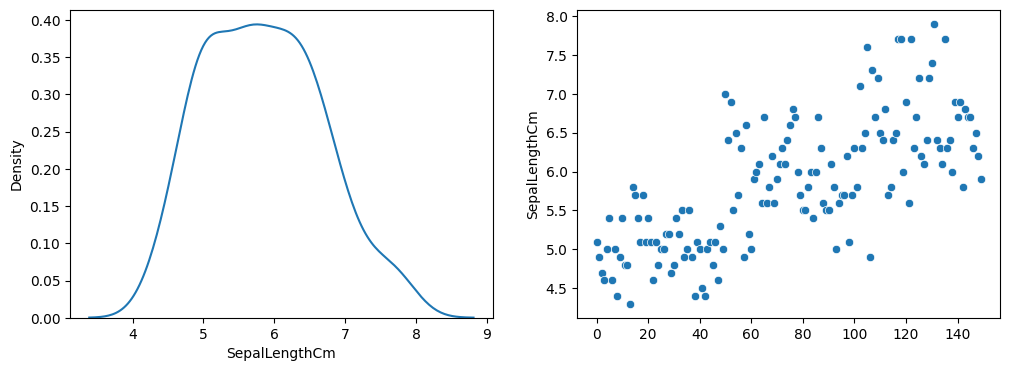

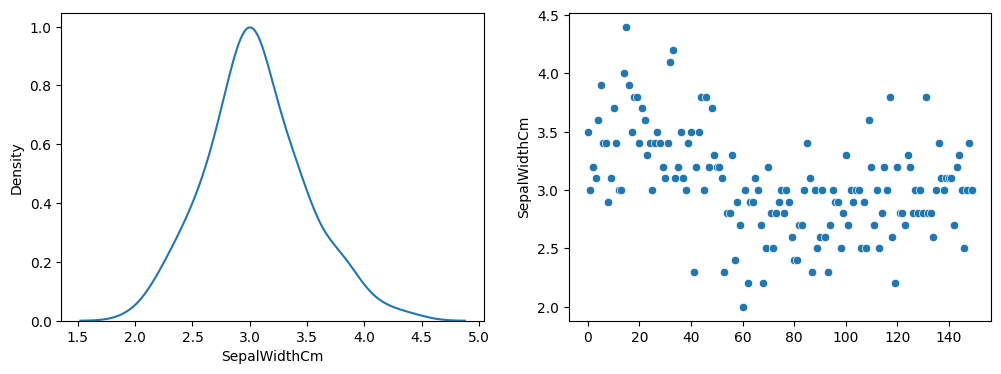

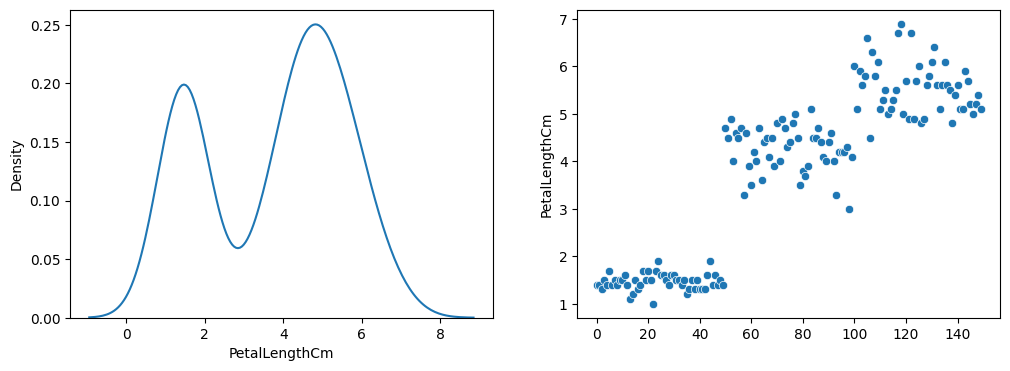

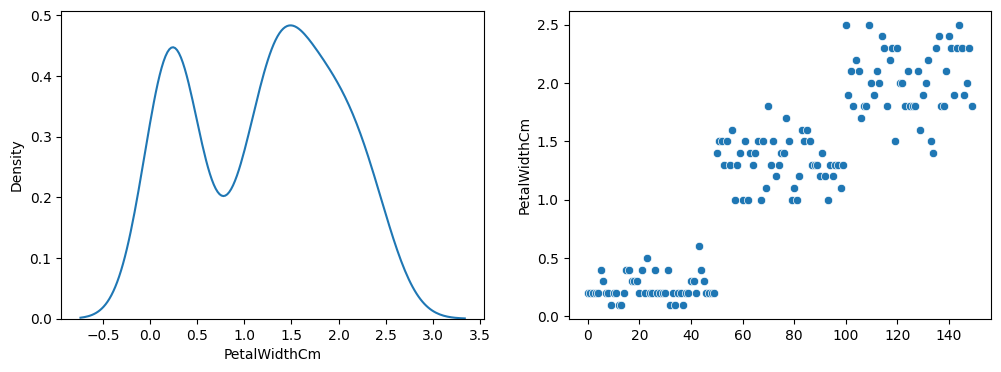

In [158]:
for i in new_df.columns:
    fig , axis = plt.subplots(1,2  , figsize=(12,4))
    sns.kdeplot(new_df[i], ax=axis[0])
    sns.scatterplot(new_df[i] , ax = axis[1])
    plt.show()

<Axes: >

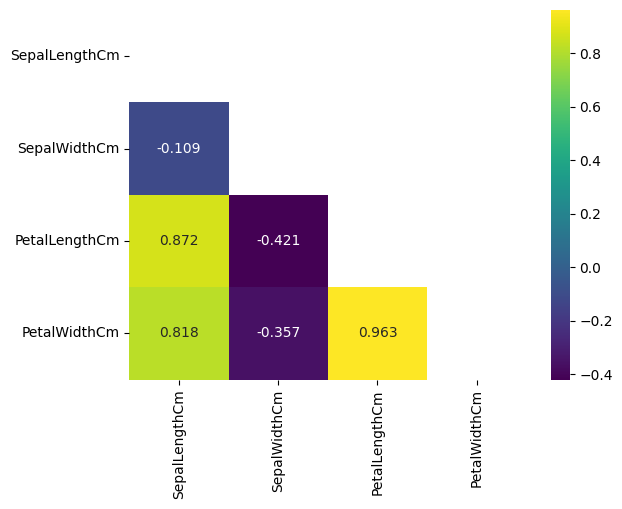

In [159]:
cor = new_df.corr()
mask =np.triu(np.ones_like(cor , dtype=bool))
sns.heatmap(cor , mask = mask , annot=True , fmt ="0.3f",cmap="viridis")

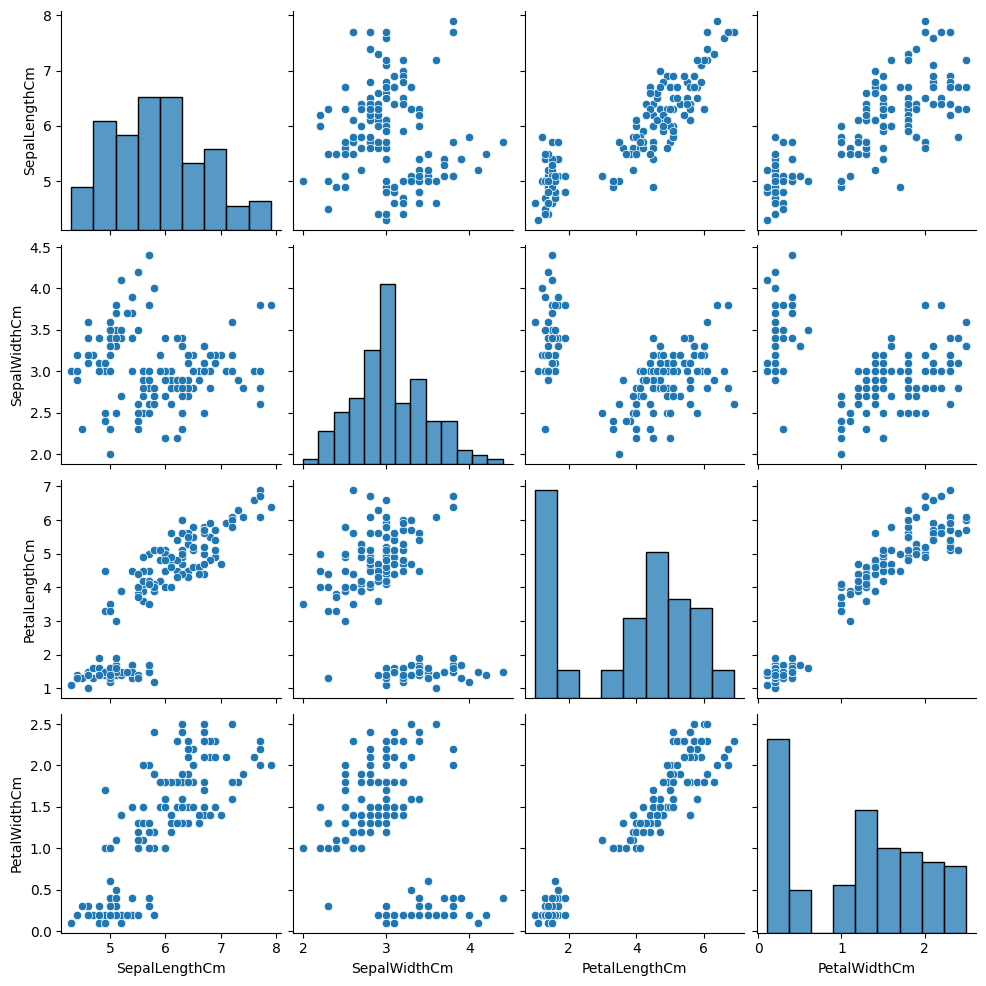

In [160]:
sns.pairplot(new_df)

In [161]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [162]:
new_df.shape

(150, 4)

In [163]:
pre = ColumnTransformer(transformers=[
    ("scale" , StandardScaler() , slice(new_df.shape[1]))
] , remainder="passthrough")

In [164]:
pipe = Pipeline(steps=[
    ("pre" , pre)
])

In [165]:
new_df = pd.DataFrame(pre.fit_transform(new_df) , columns=new_df.columns)

In [166]:
# install if needed
!pip install scikit-learn scikit-learn-extra


In [167]:
from sklearn.cluster import KMeans , MiniBatchKMeans
# from sklearn.extra.cluster  import KMedoids
from sklearn_extra.cluster import KMedoids


# K MEANS

In [168]:
k  =np.arange(2,21)
wcss=[]
for i in k:
    km =KMeans(n_clusters=i ,  init="k-means++")
    km.fit(new_df)
    wcss.append(km.inertia_)

In [169]:
!pip install kneed

Text(0.5, 1.0, '5')

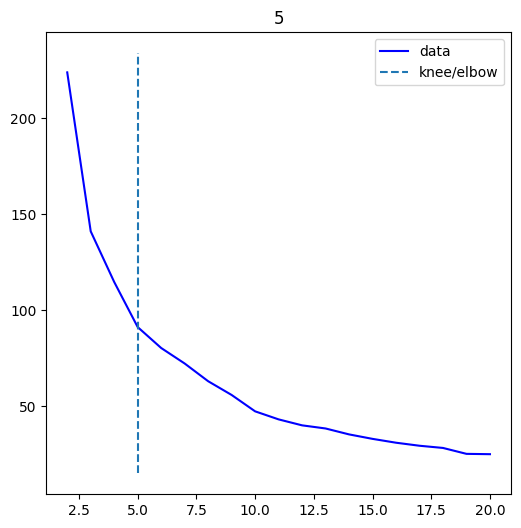

In [170]:
from kneed import KneeLocator
knee = KneeLocator(k , wcss ,direction="decreasing", curve="convex")

knee.plot_knee()
plt.title(knee.elbow)

In [171]:
algo1 = KMeans(n_clusters=5 , init="k-means++")
algo1.fit(new_df)

KMeans(n_clusters=5)

In [172]:
w=[]
for i in k:
    km= KMedoids(init="k-medoids++" , n_clusters=i)
    km.fit(new_df)
    w.append(km.inertia_)

In [173]:
kn=KneeLocator(k , w , direction="decreasing" , curve="convex")
kn.elbow
algo2= KMedoids(init="k-medoids++" , n_clusters=5)
algo2.fit(new_df)

KMedoids(init='k-medoids++', n_clusters=5)

In [174]:
from sklearn.metrics import silhouette_score

In [175]:
from sklearn.cluster import DBSCAN
e =[0.3,0.5,0.6,0.7,0.8,1.0]
p=[2,3,4,5,6,7,8,9,10]

Max = -1
params = None

for i in e:
    for j in p:
        db = DBSCAN(min_samples=j, eps=i)
        lb = db.fit_predict(new_df)

        # Skip cases with only 1 cluster or all noise
        if len(set(lb)) > 1 and not (set(lb) == {-1}):
            score = silhouette_score(new_df, lb)

            if score > Max:
                Max = score
                params = (i, j)

In [176]:
algo3=DBSCAN(min_samples=params[1] , eps=params[0])
algo3.fit(new_df)

DBSCAN(eps=1.0, min_samples=10)

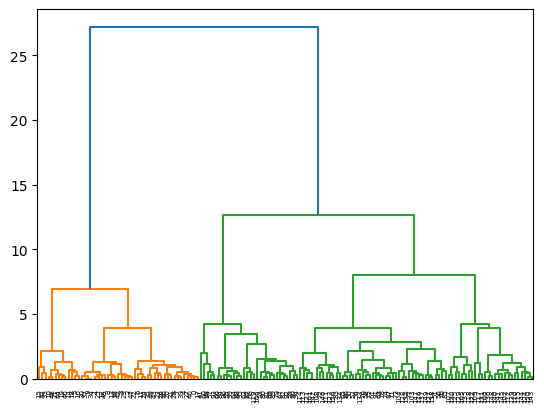

In [177]:
from scipy.cluster.hierarchy import linkage , dendrogram
cl =linkage(new_df,method="ward")
dendrogram(cl )
plt.show()

In [178]:
from sklearn.cluster import AgglomerativeClustering
algo4=AgglomerativeClustering(n_clusters=5,linkage ="ward")
algo4.fit(new_df)

AgglomerativeClustering(n_clusters=5)

In [179]:
!pip install clusteval


In [180]:
from sklearn.metrics import rand_score ,  adjusted_rand_score , silhouette_score
from  clusteval import clusteval


In [181]:
l1 = algo1.predict(new_df) # kmean
l2 = algo2.predict(new_df)# k meoids
l3 =algo3.labels_ # dbscan
l4 = algo4.fit_predict(new_df)
from sklearn.metrics import silhouette_score, davies_bouldin_score
from clusteval import clusteval

sel = []   # silhouette
dbs = []   # davies bouldin

# Silhouette (higher = better)
sel.append(silhouette_score(new_df, l1))
sel.append(silhouette_score(new_df, l2))
sel.append(silhouette_score(new_df, l3))
sel.append(silhouette_score(new_df, l4))

# Davies–Bouldin (lower = better)
dbs.append(davies_bouldin_score(new_df, l1))
dbs.append(davies_bouldin_score(new_df, l2))
dbs.append(davies_bouldin_score(new_df, l3))
dbs.append(davies_bouldin_score(new_df, l4))

# Dunn’s Index (higher = better)





In [186]:
sc= pd.DataFrame({"algo":["Kmeans", "KMedoids","DBSCAN" ,"Hierarchy"]  , "selhoute":sel  ,"davies":dbs} )

In [205]:
from sklearn.decomposition import PCA
from sklearn.manifold  import TSNE

In [206]:
per = [10, 20, 30, 40, 50]
best_score = -1
best_p = None

for i in per:
    t = TSNE(n_components=2, random_state=24, perplexity=i)
    x = t.fit_transform(new_df)

    # cluster the 2D embedding before silhouette
    labels = algo3.labels_

    s = silhouette_score(x, labels)
    print(f"Perplexity {i}: Score {s:.4f}")

    if s > best_score:
        best_score = s
        best_p = i

Perplexity 10: Score 0.4733
Perplexity 20: Score 0.5965
Perplexity 30: Score 0.6615
Perplexity 40: Score 0.6450
Perplexity 50: Score 0.5990


In [218]:
tsne= TSNE(perplexity = best_p , n_components=2)
d= pd.DataFrame(tsne.fit_transform(new_df))

In [220]:
d['y'] = algo3.labels_

In [223]:
d.columns=["1","2","y"]

In [225]:
!pip  install plotly

In [226]:
import plotly.express as exp

In [228]:
import plotly.express as px

fig = px.scatter(
    data_frame=d,      # your dataframe
    x="1",             # column for x-axis
    y="2",             # column for y-axis
    color="y"          # categorical/label column for colors
)
fig.show()


In [239]:
tsne1= TSNE(perplexity = best_p , n_components=3)
d1= pd.DataFrame(tsne1.fit_transform(new_df))

In [241]:
d1.columns= ["1","2","3"]

In [243]:
d1['y']= algo3.labels_

In [244]:
px.scatter_3d(data_frame= d1 , x="1" , y="1",z="3",color="y")